# Sales 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
sa = pd.read_csv("supermarket_sales - Sheet1.csv")

In [3]:
sa.head(2)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6


## Q1) How do sales and revenue vary over time (e.g., daily, monthly)? Chart Type: Line Chart or Bar Chart (e.g., Monthly/Weekly trends for Total or Tax 5%).

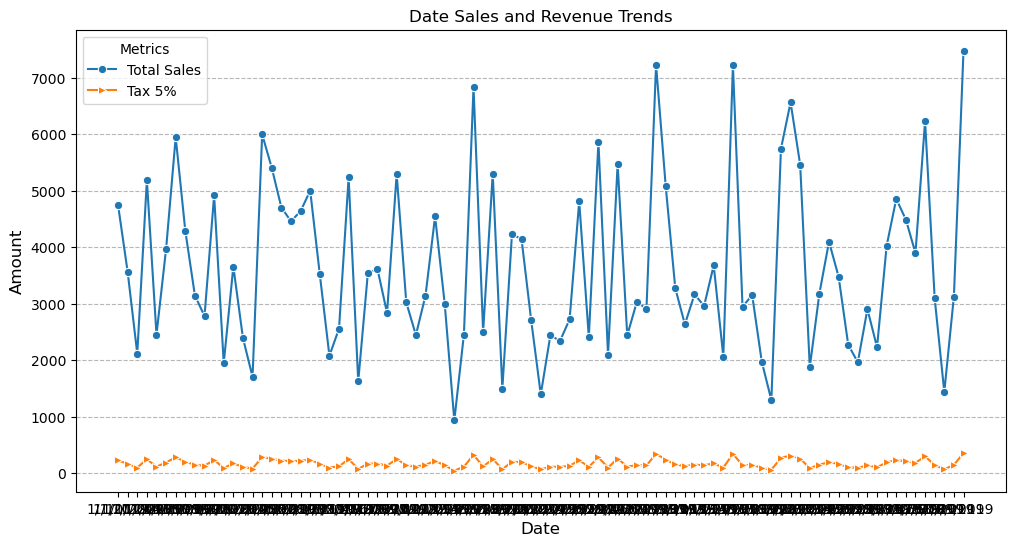

In [4]:
daily_sales = sa.groupby('Date').agg({'Total':'sum','Tax 5%' : 'sum'}).reset_index()
# Here we have used group by date and as per date we have aggregate the Total and Tax 5% into Sum

# 12,6 is figure size 
plt.figure(figsize=(12,6))

# Here we have the line chart, we have use the dail_sales as data for ploting Total sales
sns.lineplot(data = daily_sales, x = 'Date', y = 'Total', label='Total Sales', palette='rocket', marker='o')

# Here we have the line chart, we have use the dail_sales as data for ploting Tax 5%
sns.lineplot(data = daily_sales, x = 'Date', y = 'Tax 5%', label = 'Tax 5%', palette='rocket', marker='>')

# Legend is used to create a box and show the metrics in it
plt.legend(title='Metrics')

# Title to display Title for chart
plt.title('Date Sales and Revenue Trends')

# Grid is is for better visual representation like linestyle to show line on chart and alpha for the width of line
plt.grid(axis='y', linestyle = '--', alpha = 0.9)

# This is x label and Y lable and there fontsize
plt.xlabel('Date', fontsize = 12)
plt.ylabel('Amount', fontsize = 12)

plt.show()

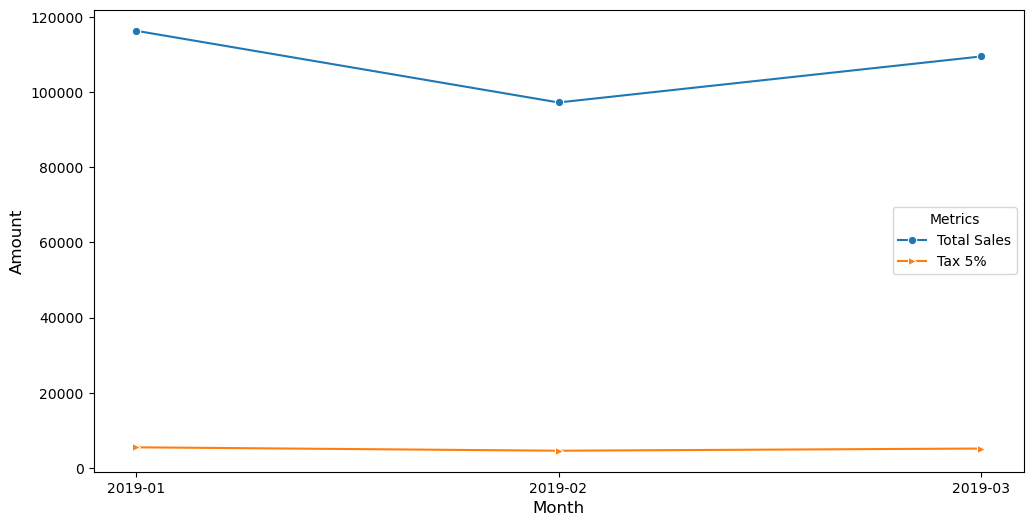

In [5]:
# Here we have go grouped date into months 
sa['Date'] = pd.to_datetime(sa['Date'], format='%m/%d/%Y', errors='coerce')

# Here we have converted month to string as seaborn can't handle it
sa['Month'] = sa['Date'].dt.to_period("M").astype(str)

# Here we have used group by Month and as per Month we have aggregate the Total and Tax 5% into Sum
monthly_sales = sa.groupby('Month').agg({'Total' : 'sum', 'Tax 5%' : 'sum'}).reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data = monthly_sales, x = 'Month', y = 'Total', palette = 'rocket' , marker = 'o', label = 'Total Sales')
sns.lineplot(data = monthly_sales, x = 'Month', y = 'Tax 5%', palette = 'rocket', marker = '>', label = 'Tax 5%')
plt.legend(title = 'Metrics')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Amount", fontsize=12)
plt.show()

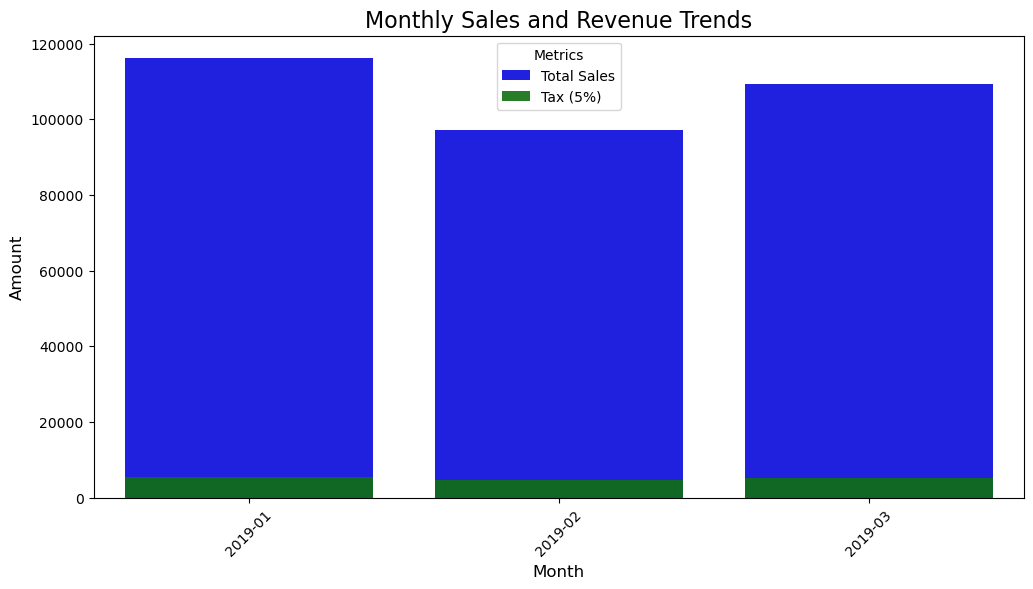

In [6]:
# Group by Month and calculate monthly total sales and tax
sa['Month'] = sa['Date'].dt.to_period("M")

# Here there was no need of conversion the month into srting


monthly_trends = sa.groupby("Month").agg({"Total": "sum", "Tax 5%": "sum"}).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_trends, x="Month", y="Total", color="blue", label="Total Sales")
sns.barplot(data=monthly_trends, x="Month", y="Tax 5%", color="green", label="Tax (5%)", alpha=0.9)
plt.title("Monthly Sales and Revenue Trends", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Amount", fontsize=12)
plt.legend(title="Metrics")
plt.xticks(rotation=45)
plt.show()

## Q2) How do the three branches (A, B, C) compare in terms of total sales and customer count? Chart Type: Grouped Bar Chart or Pie Chart for branch-wise distribution.

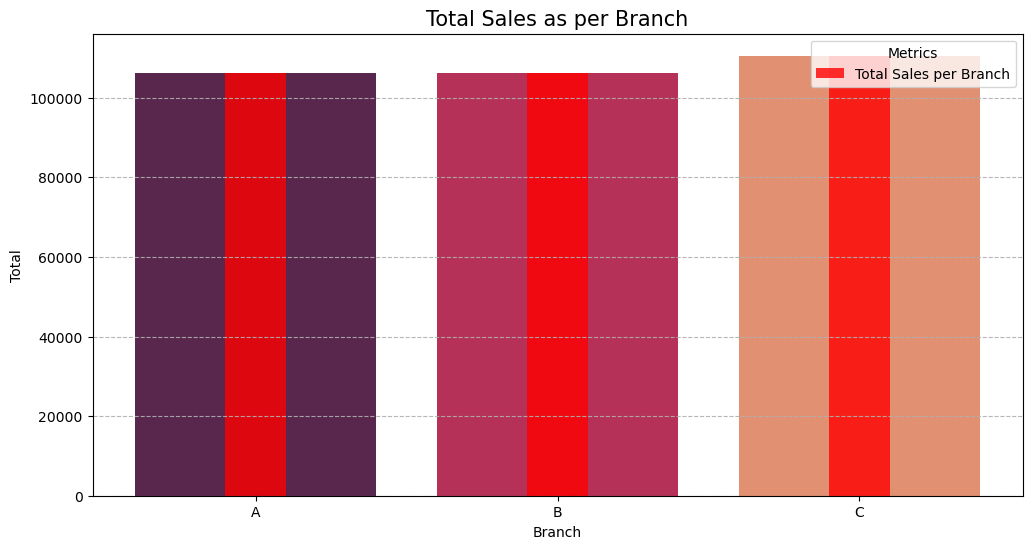

In [7]:
branch_sales = sa.groupby('Branch').agg({'Total': 'sum', 'Invoice ID' : 'count'}).reset_index()

plt.figure(figsize=(12,6))

# Get bar positions and heights from Seaborn
bar_positions = sns.barplot(
    data=branch_sales, x='Branch', y='Total', palette='rocket'
).get_xticks()
bar_heights = branch_sales['Total']

plt.bar(
    bar_positions,
    bar_heights,
    color='red',
    alpha=0.8,
    width=0.2,  # Set your desired width here
    label="Total Sales per Branch",
)

plt.legend(title='Metrics')
plt.title("Total Sales as per Branch" , fontsize = 15)
plt.grid(axis ='y', linestyle = '--', alpha = 0.9)
#sns.barplot(data = branch_sales, x = 'Branch', y = 'Invoice ID', color = 'red')

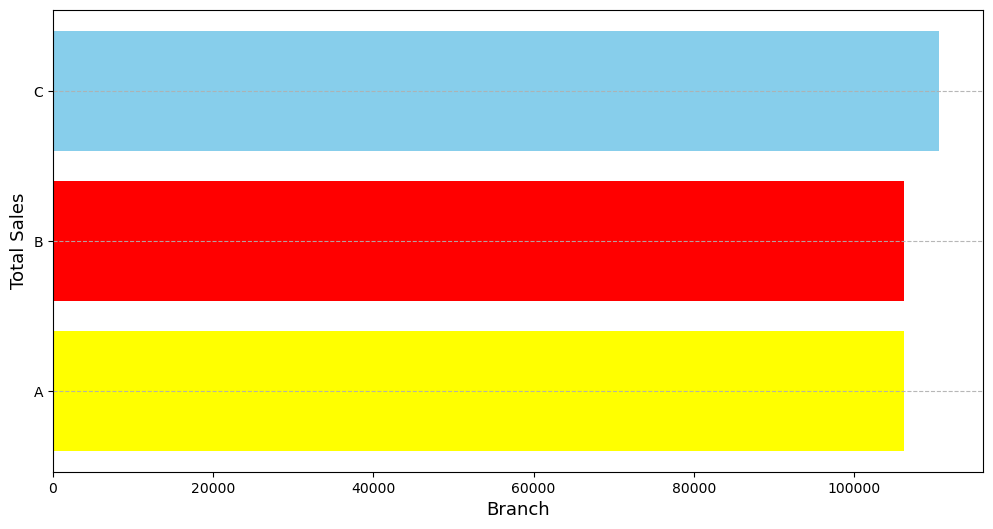

In [8]:
branch_sale = sa.groupby('Branch').agg({'Total' : 'sum', 'Invoice ID' : 'count'})

branches = branch_sales['Branch']
total_sales = branch_sales['Total']

plt.figure(figsize=(12,6))
plt.barh(branches,total_sales,color = ['yellow', 'red','skyblue'])
plt.xlabel("Branch", fontsize = 13)
plt.ylabel("Total Sales", fontsize = 13)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.9)

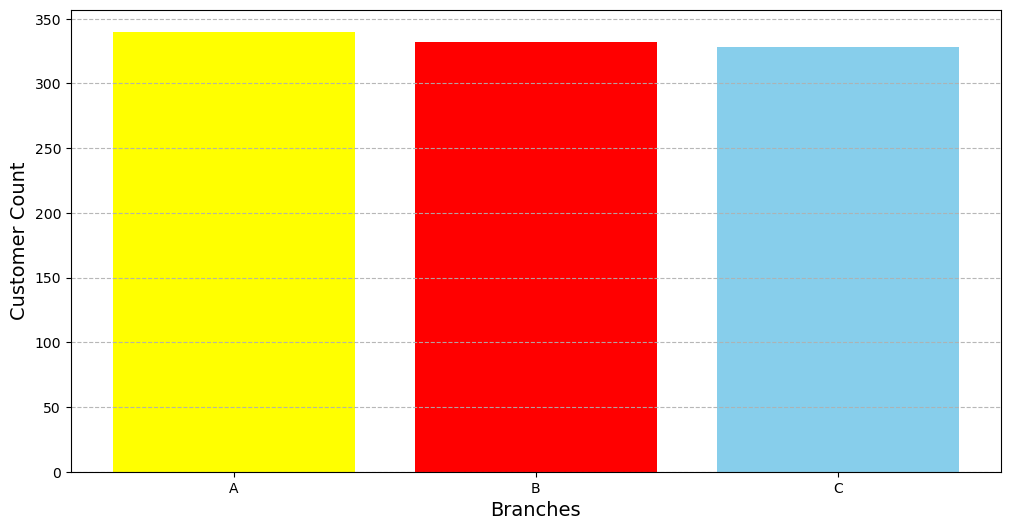

In [9]:
branch_customer_count = sa.groupby('Branch').agg({'Invoice ID': 'count'}).reset_index()

branches_count = branch_customer_count['Branch']
customer_count = branch_customer_count['Invoice ID']

plt.figure(figsize=(12,6))
plt.bar(branches_count,customer_count,color = ['Yellow','red','skyblue'])
plt.grid(axis='y', linestyle = '--', alpha = 0.9)
plt.xlabel("Branches", fontsize = 14)
plt.ylabel("Customer Count", fontsize = 14)
plt.show()

## Q3) How does total sales vary across cities (Yangon, Mandalay, Naypyitaw)? Chart Type: Pie Chart, and Heatmap.

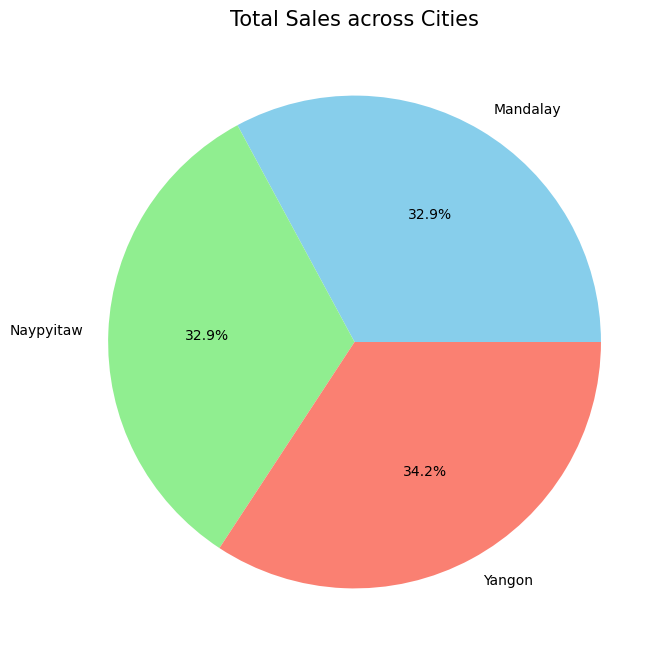

In [10]:
city_sales = sa.groupby('City').agg({'Total': 'sum'}).reset_index()

Total_sales = city_sales['Total']
city_name = city_sales['City']

plt.figure(figsize=(8,8))
plt.pie(total_sales,labels=city_name, colors=['skyblue', 'lightgreen', 'salmon'] ,autopct='%1.1f%%')
plt.title("Total Sales across Cities", fontsize = 15)
plt.show()

## Q4) What is the distribution of sales between Member and Normal customer types? Chart Type: Pie Chart

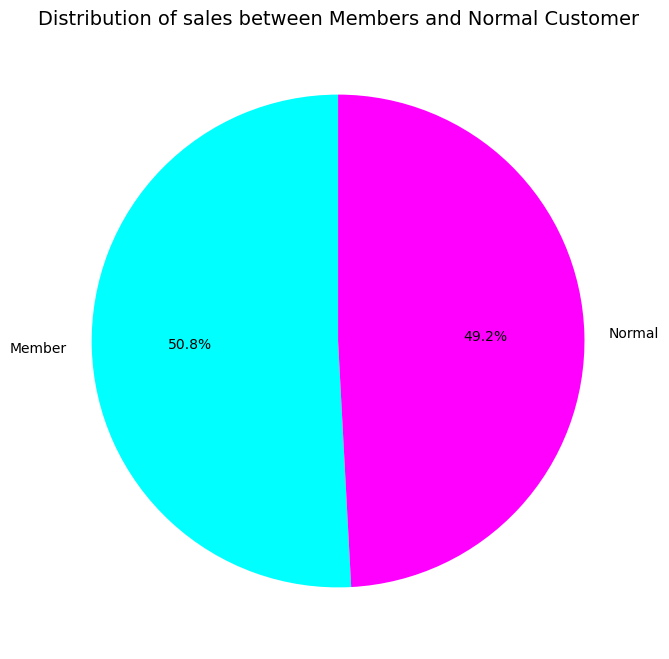

In [11]:
customer_type = sa.groupby('Customer type').agg({'Total' : 'sum'}).reset_index()

total_sales = customer_type['Total']
customer = customer_type['Customer type']

plt.figure(figsize=(8,8))
plt.pie(total_sales, labels = customer, colors = ['cyan', 'magenta'], autopct = '%1.1f%%',startangle=90 )
plt.title("Distribution of sales between Members and Normal Customer", fontsize = 14)
plt.show()

## Q5) How do male and female customers contribute to total revenue or frequency of purchases? Chart Type: Pie Chart or Grouped Bar Chart.

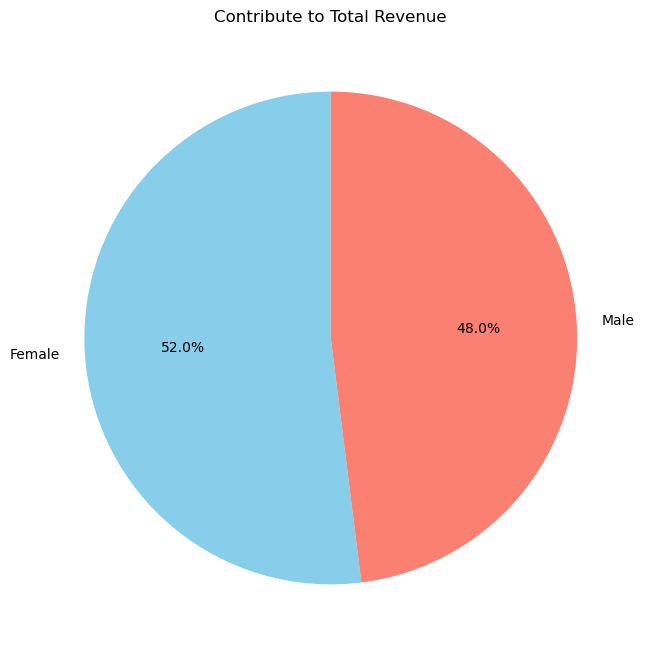

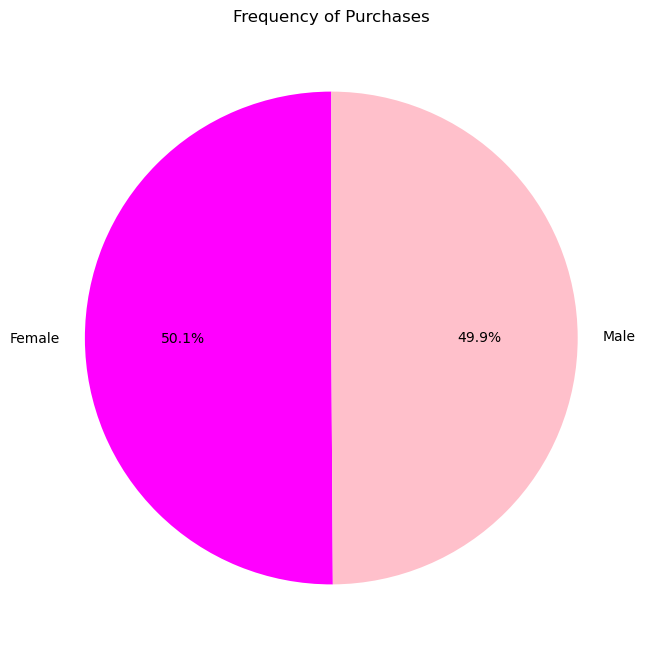

In [12]:
gender_sales = sa.groupby('Gender').agg({'Total' : 'sum', 'Invoice ID' : 'count'}).reset_index()

total_sales = gender_sales['Total']
gender_mf = gender_sales['Gender']
frequencies = gender_sales['Invoice ID']

plt.figure(figsize=(8,8))
plt.pie(total_sales, labels = gender_mf , colors = ['skyblue', 'salmon'], autopct = '%1.1f%%', startangle = 90)
plt.title("Contribute to Total Revenue")
plt.show()


plt.figure(figsize=(8,8))
plt.pie(frequencies, labels = gender_mf , colors = ['magenta','pink'], autopct = '%1.1f%%', startangle=90)
plt.title("Frequency of Purchases")
plt.show()

## Q6) Which product line contributes the most to revenue (Total) or quantity sold? Chart Type: Horizontal Bar Chart or Treemap.

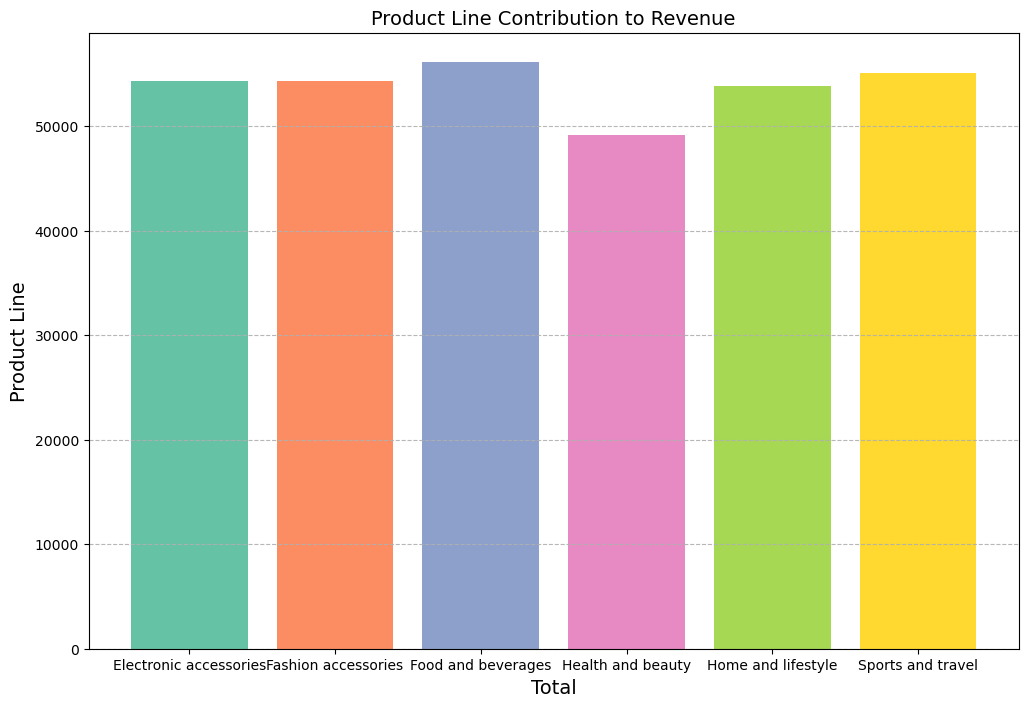

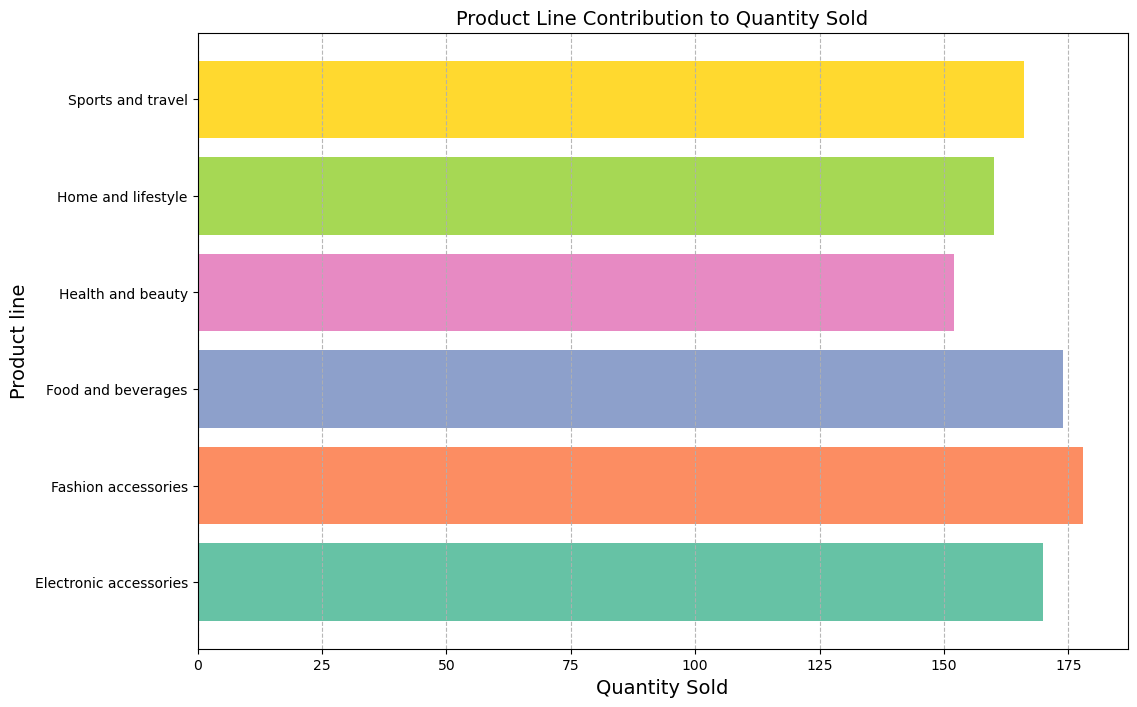

In [13]:
product = sa.groupby('Product line').agg({'Total' : 'sum', 'Invoice ID' : 'count'}).reset_index()

product_line = product['Product line']
total = product['Total']
quantity_sold = product['Invoice ID']

colors = ['#66c2a5',  # Teal
          '#fc8d62',  # Coral
          '#8da0cb',  # Blue
          '#e78ac3',  # Pink
          '#a6d854',  # Green
          '#ffd92f']  # Yellow)

plt.figure(figsize=(12,8))
plt.bar(product_line,total,color = colors)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.9)
plt.xlabel("Total", fontsize = 14)
plt.ylabel("Product Line", fontsize = 14)
plt.title('Product Line Contribution to Revenue', fontsize=14)
plt.show()


plt.figure(figsize=(12,8))
plt.barh(product_line,quantity_sold, color = colors)
plt.grid(axis = 'x', linestyle = '--', alpha = 0.9)
plt.xlabel("Quantity Sold", fontsize = 14)
plt.ylabel("Product line", fontsize = 14)
plt.title('Product Line Contribution to Quantity Sold', fontsize=14)
plt.show()


## Q7) What is the distribution of payment methods (Ewallet, Cash, Credit card) used by customers? Chart Type: Pie Chart or Bar Chart.

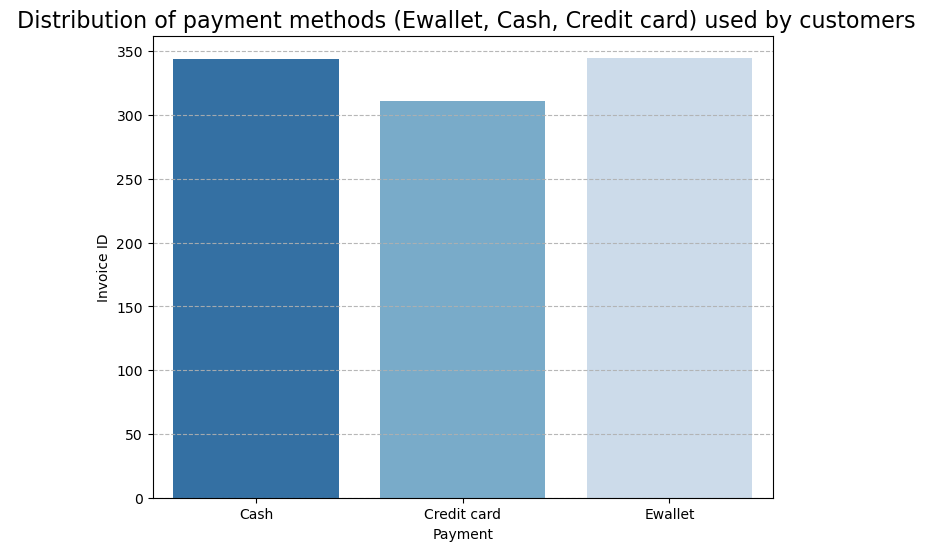

In [14]:
payment_method = sa.groupby('Payment').agg({'Invoice ID' : 'count'}).reset_index()

plt.figure(figsize=(8,6))
sns.barplot( data = payment_method, x = 'Payment', y = 'Invoice ID',palette = 'Blues_r')
plt.title(' Distribution of payment methods (Ewallet, Cash, Credit card) used by customers',fontsize = 16)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.9)
plt.show()

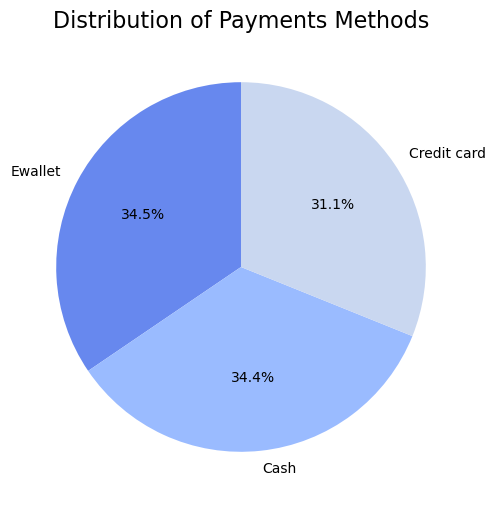

In [15]:
payment_method = sa['Payment'].value_counts()

payment = payment_method.index
payment_counts = payment_method.values

colors = sns.color_palette('coolwarm')

plt.figure(figsize=(8,6))
plt.pie(payment_counts, labels = payment, autopct = '%1.1f%%', startangle = 90, colors = colors)
plt.title("Distribution of Payments Methods", fontsize = 16)
plt.show()

## Q8) What is the distribution of customer ratings? Does it vary across product lines or branches? Chart Type: Histogram or Box Plot

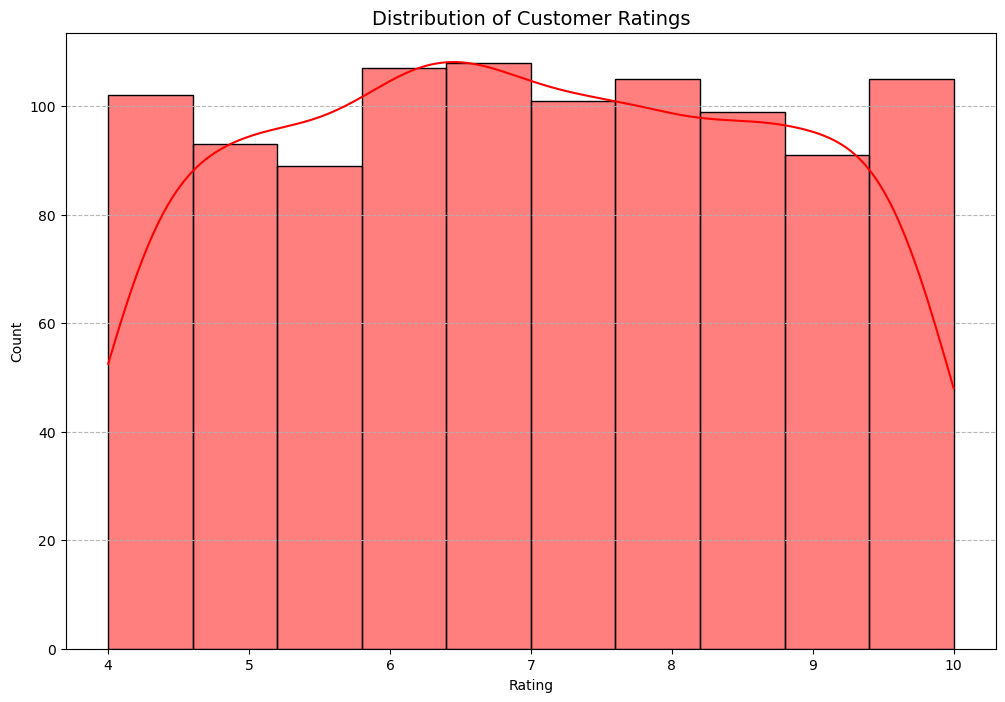

In [16]:
plt.figure(figsize=(12,8))
sns.histplot(data = sa, x = 'Rating',edgecolor='black',bins=10, kde=True, color = 'red')
plt.title('Distribution of Customer Ratings', fontsize=14)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.9)
plt.show()

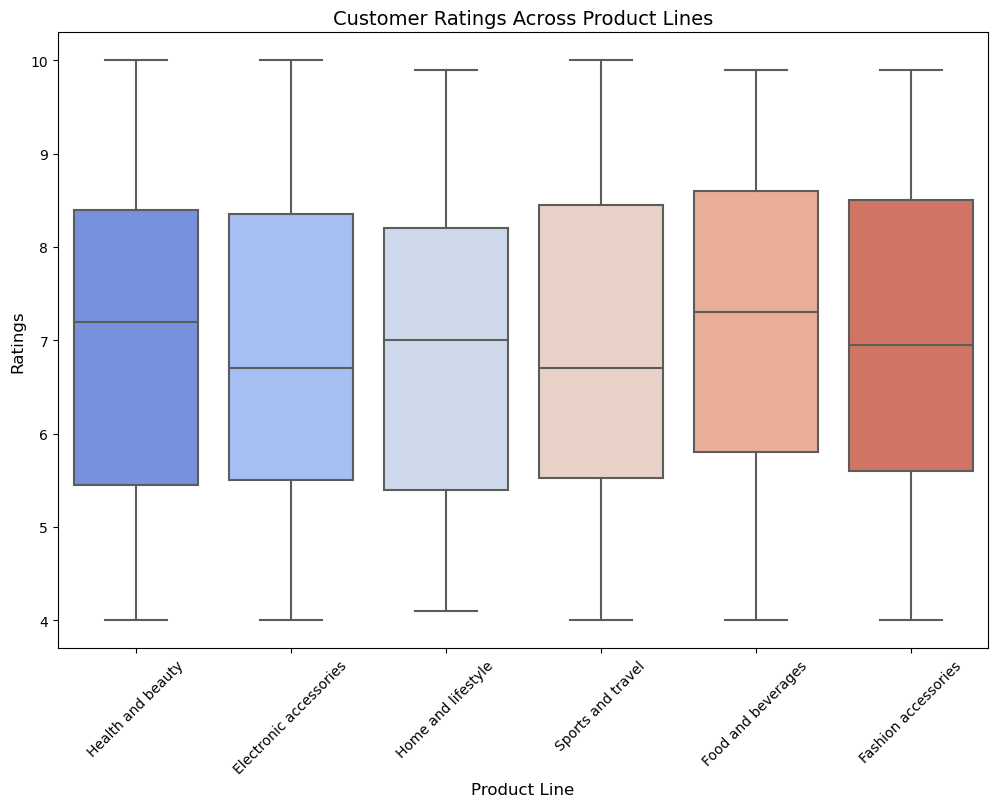

In [17]:
plt.figure(figsize=(12,8))
sns.boxplot(data = sa , x = 'Product line',y = 'Rating',palette = 'coolwarm')
plt.title('Customer Ratings Across Product Lines', fontsize=14)
plt.xlabel('Product Line', fontsize=12)
plt.ylabel('Ratings', fontsize=12)
plt.xticks(rotation=45)

plt.show()

## Q9) Are there any noticeable trends in sales based on Time (e.g., peak sales hours)? Chart Type: Line Chart or Heatmap (time vs. total sales).

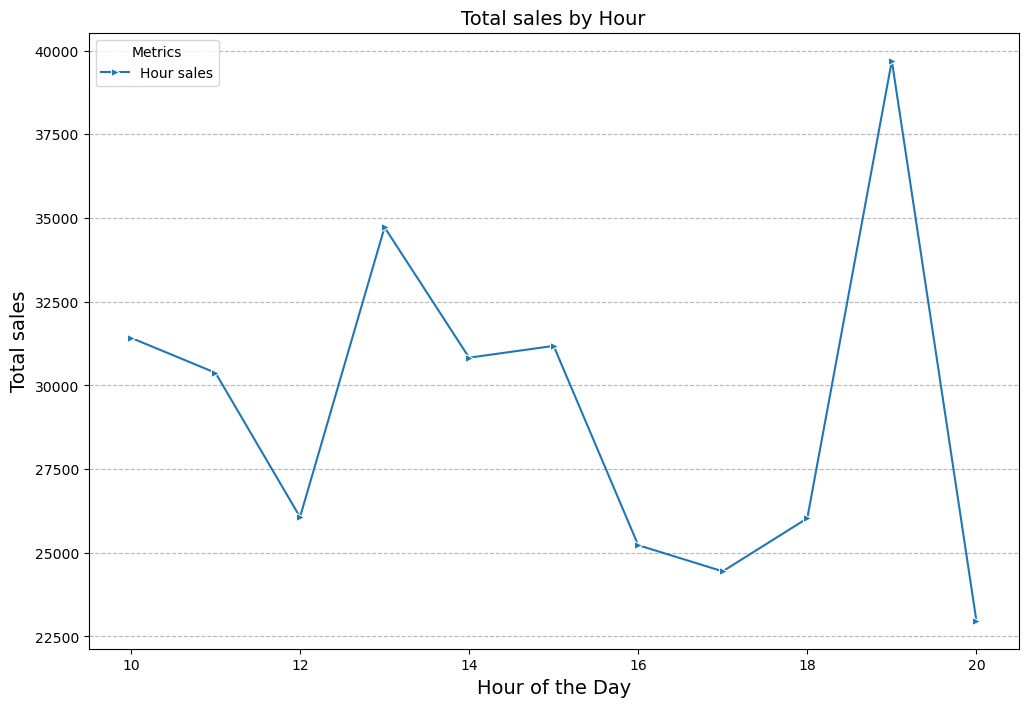

In [18]:
sa['Hour'] = sa['Time'].apply(lambda x: int(x.split(':')[0]))

time_sales = sa.groupby('Hour').agg({'Total' : 'sum'}).reset_index()

plt.figure(figsize=(12,8))
sns.lineplot(data = time_sales, x = 'Hour',y = 'Total', marker = '>', palette = 'rocket', label = 'Hour sales')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.9)
plt.xlabel('Hour of the Day', fontsize = 14)
plt.ylabel('Total sales', fontsize = 14)
plt.title("Total sales by Hour", fontsize = 14)
plt.legend(title = 'Metrics')
plt.show()

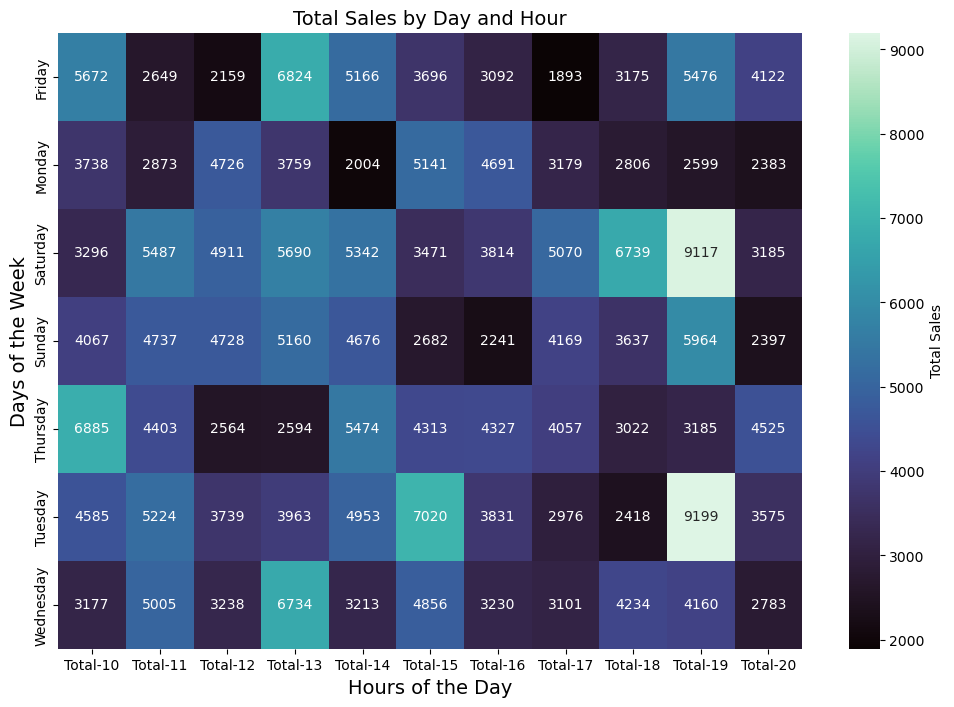

In [19]:
sa['Day'] = sa['Date'].dt.day_name()

heat_map = sa.groupby(['Day','Hour']).agg({'Total' : 'sum'}).unstack()

plt.figure(figsize=(12,8))
sns.heatmap(heat_map,cmap = 'mako',annot=True, fmt='.0f', cbar_kws={'label': 'Total Sales'})
plt.title("Total Sales by Day and Hour", fontsize = 14)
plt.xlabel("Hours of the Day", fontsize = 14)
plt.ylabel("Days of the Week", fontsize = 14)
plt.show()

## Q10) How does gross income (gross income) vary across branches, cities, or product lines? Chart Type: Stacked Bar Chart or Line Chart.

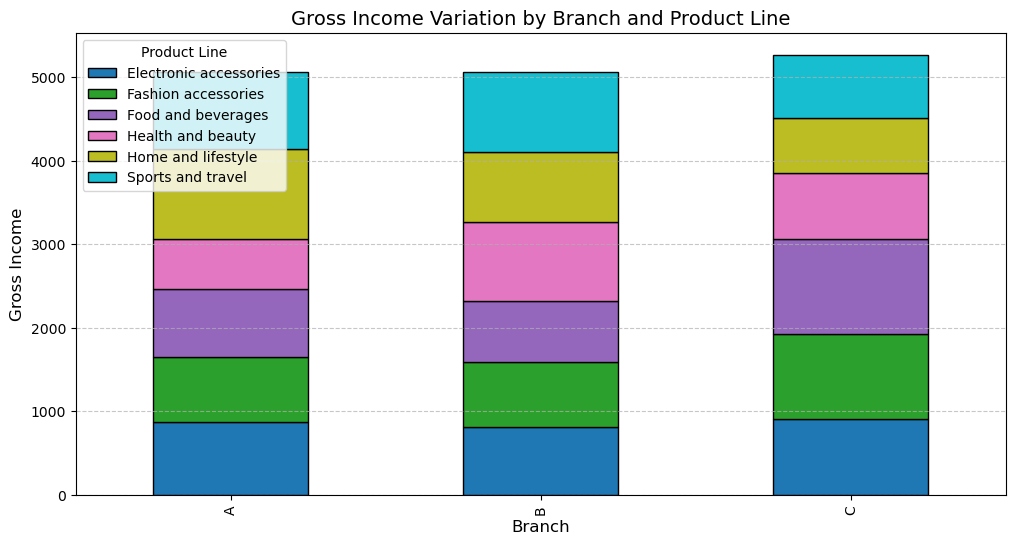

In [20]:
gross_income_data = sa.groupby(['Branch','City','Product line']).agg({'gross income' : 'sum'}).reset_index()

pivot_data = gross_income_data.pivot(index='Branch', columns='Product line', values='gross income')

# Plotting the Stacked Bar Chart
pivot_data.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10', edgecolor='black')

# Adding labels and title
plt.title('Gross Income Variation by Branch and Product Line', fontsize=14)
plt.xlabel('Branch', fontsize=12)
plt.ylabel('Gross Income', fontsize=12)
plt.legend(title='Product Line')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

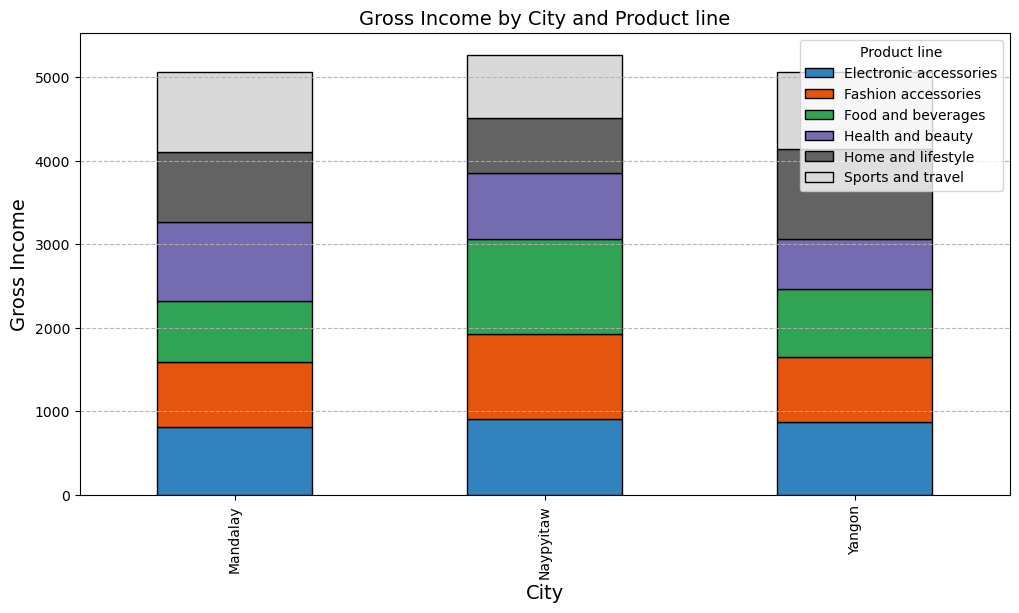

In [21]:
gross_income = sa.groupby(['City','Product line']).agg({'gross income' : 'sum'}).reset_index()

pivotdata = gross_income.pivot(index = 'City', columns = 'Product line', values = 'gross income')


pivotdata.plot(kind = 'bar', stacked =True, figsize = (12,6), colormap = 'tab20c', edgecolor = 'black')

plt.title("Gross Income by City and Product line", fontsize = 14)
plt.xlabel("City", fontsize = 14)
plt.ylabel("Gross Income", fontsize = 14)
plt.legend(title = 'Product line')
plt.grid(axis = 'y', linestyle = '--' , alpha = 0.9)
plt.show()

## Q11) Which product line or branch contributes the most to total tax (Tax 5%)? Chart Type: Horizontal Bar Chart or Treemap.

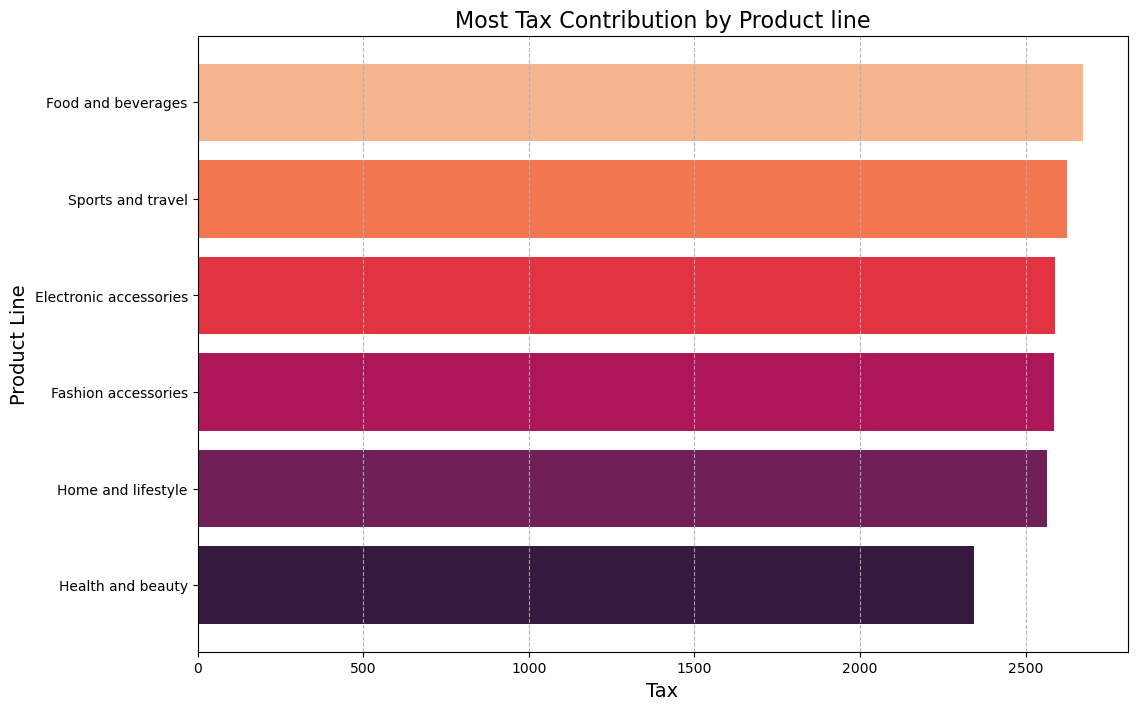

In [22]:
tax_rate = sa.groupby(['Product line']).agg({'Tax 5%' : 'sum'}).reset_index()

tax_rate = tax_rate.sort_values(by ='Tax 5%', ascending = True)

tax = tax_rate['Tax 5%']
product = tax_rate['Product line']
#branch = tax_rate['Branch']

colors = sns.color_palette('rocket')

plt.figure(figsize=(12,8))
plt.barh(product,tax,color = colors)
plt.title("Most Tax Contribution by Product line" , fontsize = 16)
plt.xlabel("Tax" , fontsize = 14)
plt.ylabel("Product Line" , fontsize = 14)
plt.grid(axis = 'x', linestyle = '--', alpha = 0.9)
plt.show()

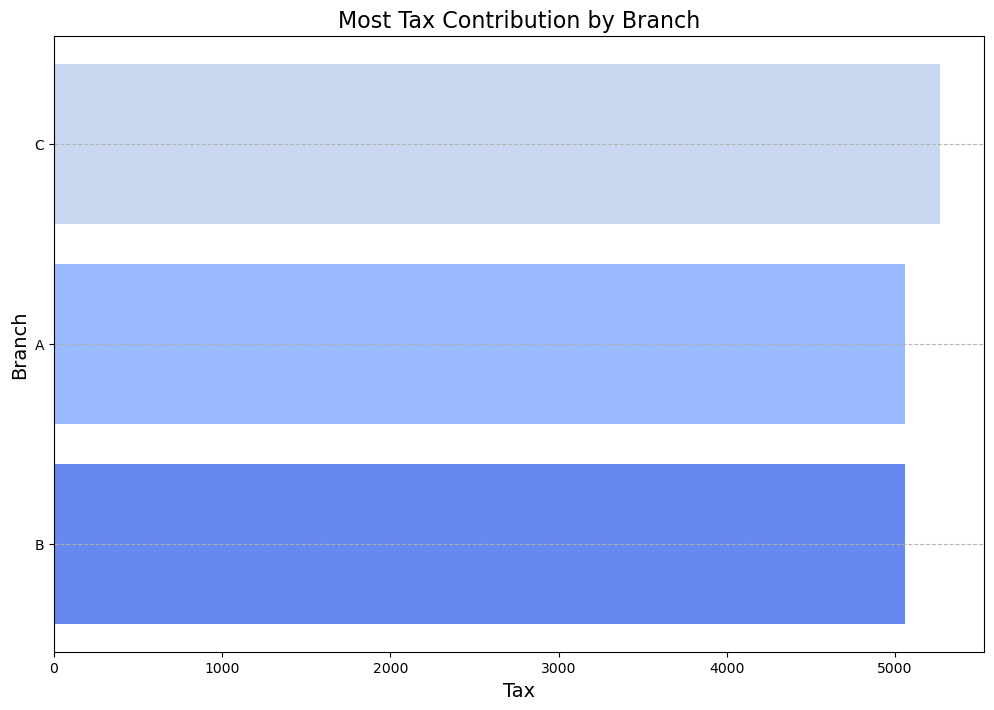

In [23]:
tax_rate_branch = sa.groupby('Branch').agg({'Tax 5%' : 'sum'}).reset_index()

tax_rate_branch = tax_rate_branch.sort_values(by = 'Tax 5%', ascending = True)

tax = tax_rate_branch['Tax 5%']
#product = tax_rate['Product line']
branch = tax_rate_branch['Branch']

colors = sns.color_palette('coolwarm')

plt.figure(figsize=(12,8))
plt.barh(branch,tax,color = colors)
plt.title("Most Tax Contribution by Branch", fontsize = 16)
plt.xlabel("Tax",fontsize = 14)
plt.ylabel("Branch",fontsize = 14)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.9)
plt.show()

## Q12) What is the average or total quantity sold for each product line? Chart Type: Grouped Bar Chart.

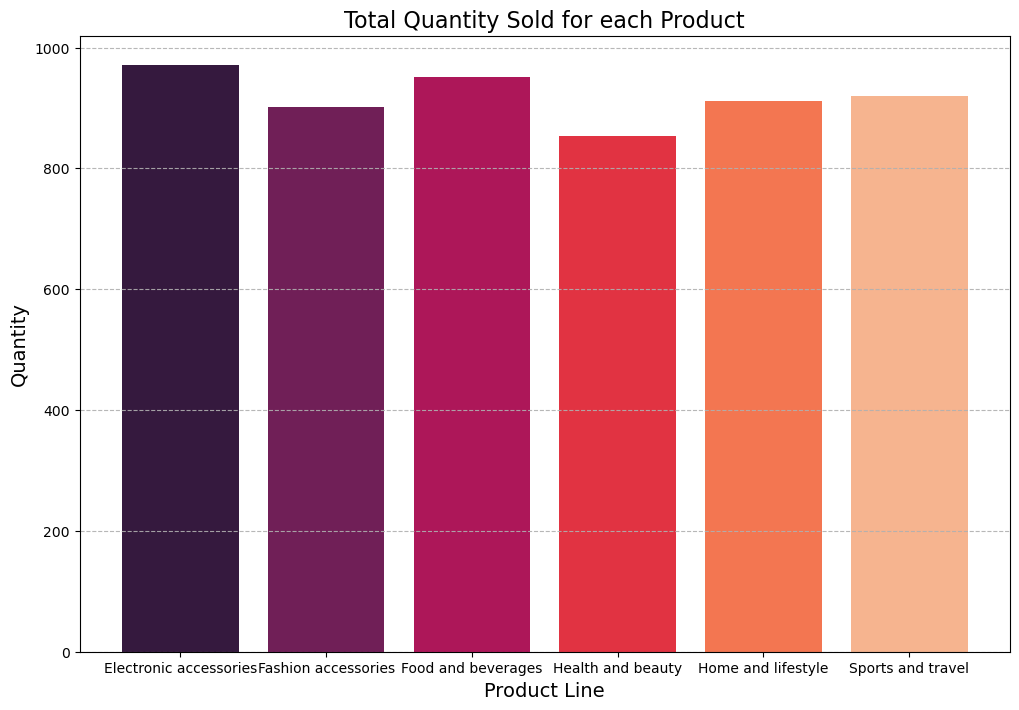

In [24]:
total_quantity = sa.groupby('Product line').agg({'Quantity' : 'sum'}).reset_index()

product_line = total_quantity['Product line']
total = total_quantity['Quantity']
colors = sns.color_palette('rocket')

plt.figure(figsize=(12,8))
plt.bar(product_line,total,color = colors)
plt.title("Total Quantity Sold for each Product",fontsize = 16)
plt.ylabel("Quantity", fontsize = 14)
plt.xlabel("Product Line", fontsize = 14)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.9)
plt.show()

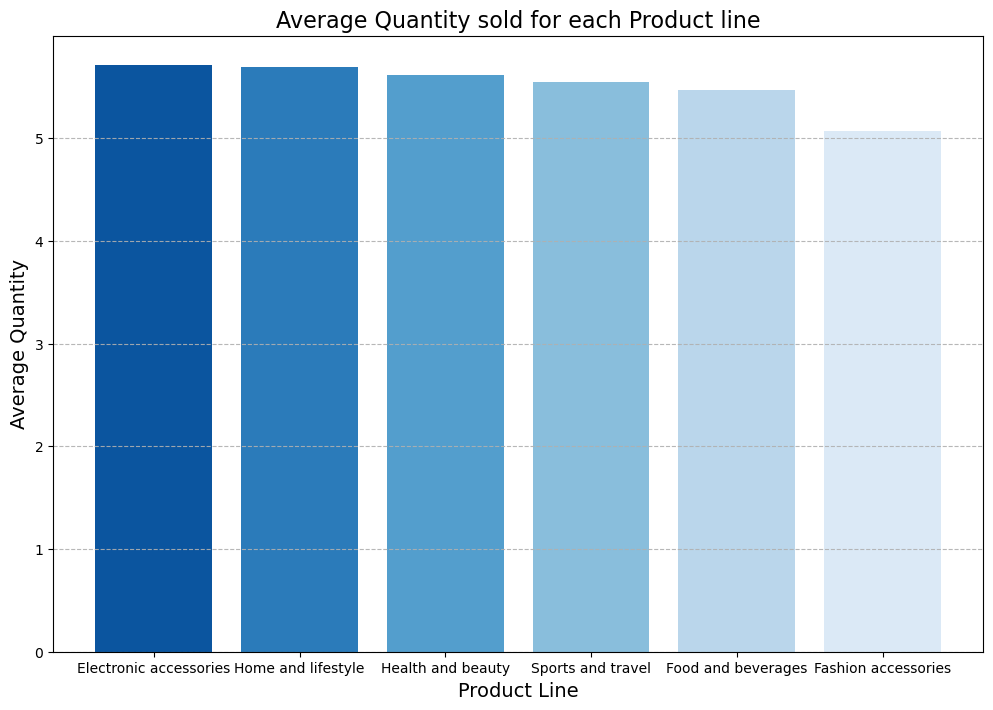

In [25]:
average_quantity = sa.groupby('Product line').agg({'Quantity' : 'mean'}).reset_index()

average_quantity = average_quantity.sort_values(by = 'Quantity', ascending = False)

average = average_quantity['Quantity']
product = average_quantity['Product line']

colors = sns.color_palette('Blues_r')

plt.figure(figsize=(12,8))
plt.bar(product,average,color = colors)
plt.title("Average Quantity sold for each Product line",fontsize = 16)
plt.xlabel("Product Line", fontsize = 14)
plt.ylabel("Average Quantity", fontsize = 14)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.9)
plt.show()

## Q13) How do the different product lines contribute to overall sales (Total)? Chart Type: Pie Chart

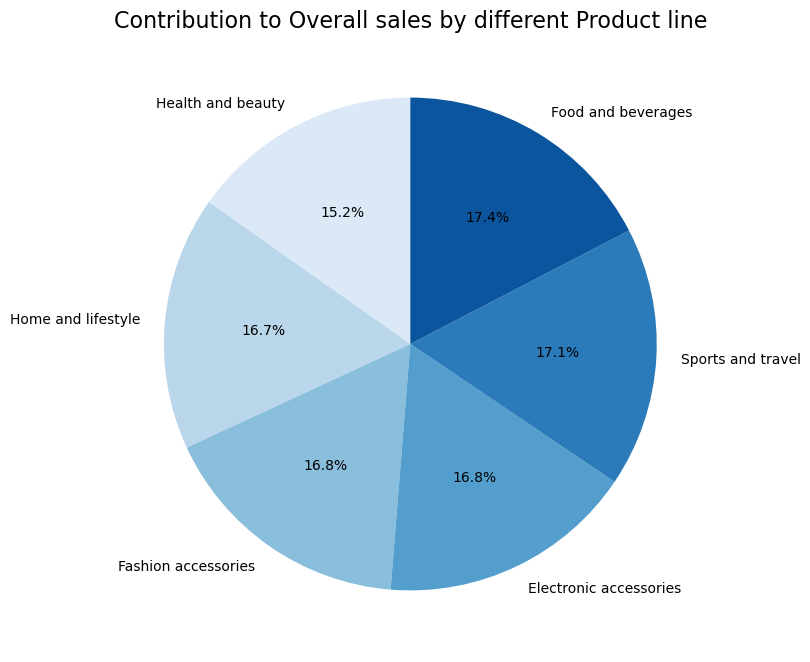

In [26]:
product_sales = sa.groupby('Product line').agg({'Total' : 'sum'}).reset_index()

product_sales = product_sales.sort_values(by = 'Total', ascending = True)

total = product_sales['Total']
product_line = product_sales['Product line']

colors = sns.color_palette('Blues')

plt.figure(figsize=(12,8))
plt.pie(total, labels = product_line , autopct = '%1.1f%%', startangle = 90, colors = colors)
plt.title("Contribution to Overall sales by different Product line", fontsize = 16)
plt.show()